<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Log_reg__KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print(" Step 1: Connecting to Google Drive...")
drive.mount('/content/drive')

 Step 1: Connecting to Google Drive...
Mounted at /content/drive



 Step 2: Locating the preprocessed Super-Dataset...
 SUCCESS! Loaded your preprocessed super-dataset from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv
   Dimensions: 4756 rows, 65 columns

 Step 3: Training Logistic Regression Model...

 TEAM EVALUATION REPORT 
 Baseline Validation ROC-AUC: 0.8290

 Classification Performance Metrics:
                    precision    recall  f1-score   support

Not Vaccinated (0)       0.82      0.90      0.86       641
    Vaccinated (1)       0.75      0.59      0.66       311

          accuracy                           0.80       952
         macro avg       0.78      0.75      0.76       952
      weighted avg       0.80      0.80      0.79       952



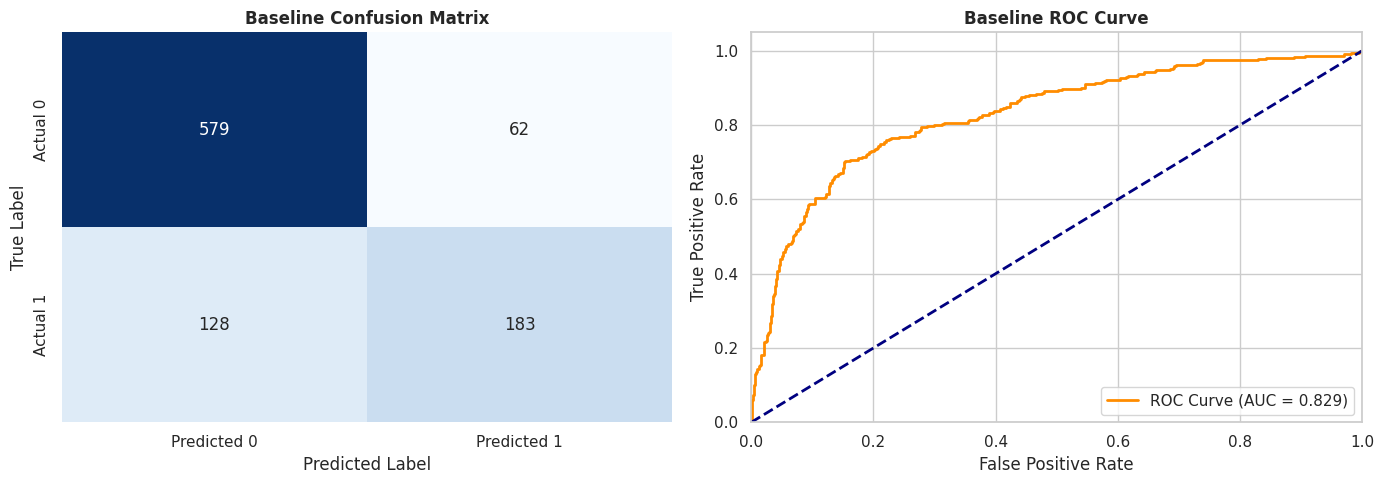


 Validation charts saved directly to your shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/team_logistic_baseline_evaluation.png


In [ ]:


# 2. LOCATE YOUR PREPROCESSED SUPER-DATASET

print("\n Step 2: Locating the preprocessed Super-Dataset...")
# This looks for the clean, engineered file you saved earlier
search_pattern = ''
matching_files = glob.glob(search_pattern)

if len(matching_files) == 0:
    # Backup date folder check
    matching_files = glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(matching_files) > 0:
    file_path = matching_files[0]
    df_super = pd.read_csv(file_path)
    print(f" SUCCESS! Loaded your preprocessed super-dataset from: {file_path}")
    print(f"   Dimensions: {df_super.shape[0]} rows, {df_super.shape[1]} columns")
else:
    raise FileNotFoundError(
        " ERROR: Could not find 'super_dataset_C_train.csv'.\n"
        " FIX: Make sure you ran the export step on your laptop to save the file into the shared folder!"
    )

# 3. SPLIT THE PRE-CLEANED DATA

# The super-dataset already has everything scaled and encoded, target included!
y_model = df_super['covid_vaccine']
X_model = df_super.drop(columns=['covid_vaccine'])

# 20% validation split, stratified to handle the class balance perfectly
X_train, X_val, y_train, y_val = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)


# 4. TRAIN LOGISTIC REGRESSION

print("\n Step 3: Training Logistic Regression Model...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_val)
y_pred_proba = log_reg.predict_proba(X_val)[:, 1]


# 5. PRINT TEAM PERFORMANCE REPORT

print("\n TEAM EVALUATION REPORT ")
auc_score = roc_auc_score(y_val, y_pred_proba)
print(f" Baseline Validation ROC-AUC: {auc_score:.4f}\n")
print(" Classification Performance Metrics:")
print(classification_report(y_val, y_pred, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))


# 6. VISUALIZE AND SAVE CHARTS

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('Baseline Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Baseline ROC Curve', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()

# Save evaluation plot right back into the folder
output_plot_path = file_path.replace('super_dataset_C_train.csv', 'team_logistic_baseline_evaluation.png')
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Validation charts saved directly to your shared Drive folder at:\n   {output_plot_path}")

## K-Nearest Neighbors (KNN) Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("Step 4: Training K-Nearest Neighbors Model...")
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a starting point
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_val)
y_pred_proba_knn = knn_model.predict_proba(X_val)[:, 1]


Step 4: Training K-Nearest Neighbors Model...


In [ ]:
print(" KNN MODEL EVALUATION REPORT ")
auc_score_knn = roc_auc_score(y_val, y_pred_proba_knn)
print(f"KNN Validation ROC-AUC: {auc_score_knn:.4f}\n")
print("KNN Classification Performance Metrics:")
print(classification_report(y_val, y_pred_knn, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))


 KNN MODEL EVALUATION REPORT 
KNN Validation ROC-AUC: 0.6859

KNN Classification Performance Metrics:
                    precision    recall  f1-score   support

Not Vaccinated (0)       0.76      0.85      0.80       641
    Vaccinated (1)       0.59      0.44      0.50       311

          accuracy                           0.72       952
         macro avg       0.68      0.65      0.65       952
      weighted avg       0.70      0.72      0.71       952



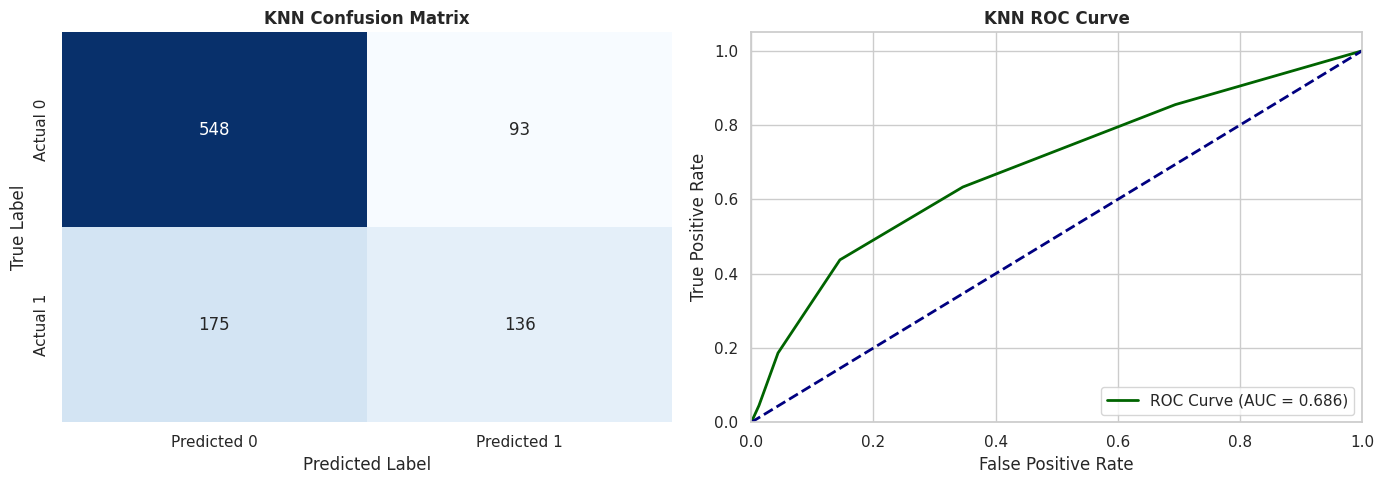

KNN validation charts saved directly to your shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/team_knn_baseline_evaluation.png


In [ ]:
sns.set_theme(style="whitegrid")
fig_knn, axes_knn = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_val, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes_knn[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes_knn[0].set_title('KNN Confusion Matrix', fontweight='bold')
axes_knn[0].set_xlabel('Predicted Label')
axes_knn[0].set_ylabel('True Label')

# ROC Curve for KNN
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_pred_proba_knn)
axes_knn[1].plot(fpr_knn, tpr_knn, color='darkgreen', lw=2, label=f'ROC Curve (AUC = {auc_score_knn:.3f})')
axes_knn[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes_knn[1].set_xlim([0.0, 1.0])
axes_knn[1].set_ylim([0.0, 1.05])
axes_knn[1].set_xlabel('False Positive Rate')
axes_knn[1].set_ylabel('True Positive Rate')
axes_knn[1].set_title('KNN ROC Curve', fontweight='bold')
axes_knn[1].legend(loc="lower right")

plt.tight_layout()

# Save KNN evaluation plot
output_plot_path_knn = file_path.replace('super_dataset_C_train.csv', 'team_knn_baseline_evaluation.png')
plt.savefig(output_plot_path_knn, dpi=300, bbox_inches='tight')
plt.show()

print(f"KNN validation charts saved directly to your shared Drive folder at:\n   {output_plot_path_knn}")


## Hyperparameter Tuning for KNN using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n Step 5: Performing GridSearchCV for KNN hyperparameter tuning...")

# Define the parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize GridSearchCV
knn_grid_search = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
knn_grid_search.fit(X_train, y_train)

print("GridSearchCV complete.")


 Step 5: Performing GridSearchCV for KNN hyperparameter tuning...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV complete.


In [ ]:
print("\n GridSearchCV Results for KNN ")
print(f"Best parameters for KNN: {knn_grid_search.best_params_}")
print(f"Best ROC-AUC score for KNN: {knn_grid_search.best_score_:.4f}")

# Get the best KNN model
best_knn_model = knn_grid_search.best_estimator_



 GridSearchCV Results for KNN 
Best parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best ROC-AUC score for KNN: 0.7620


In [ ]:
print("\n Optimized KNN MODEL EVALUATION REPORT ")
y_pred_best_knn = best_knn_model.predict(X_val)
y_pred_proba_best_knn = best_knn_model.predict_proba(X_val)[:, 1]

auc_score_best_knn = roc_auc_score(y_val, y_pred_proba_best_knn)
print(f" Optimized KNN Validation ROC-AUC: {auc_score_best_knn:.4f}\n")
print("Optimized KNN Classification Performance Metrics:")
print(classification_report(y_val, y_pred_best_knn, target_names=['Not Vaccinated (0)', 'Vaccinated (1)']))



 Optimized KNN MODEL EVALUATION REPORT 
 Optimized KNN Validation ROC-AUC: 0.7212

Optimized KNN Classification Performance Metrics:
                    precision    recall  f1-score   support

Not Vaccinated (0)       0.76      0.88      0.82       641
    Vaccinated (1)       0.64      0.42      0.51       311

          accuracy                           0.73       952
         macro avg       0.70      0.65      0.66       952
      weighted avg       0.72      0.73      0.72       952



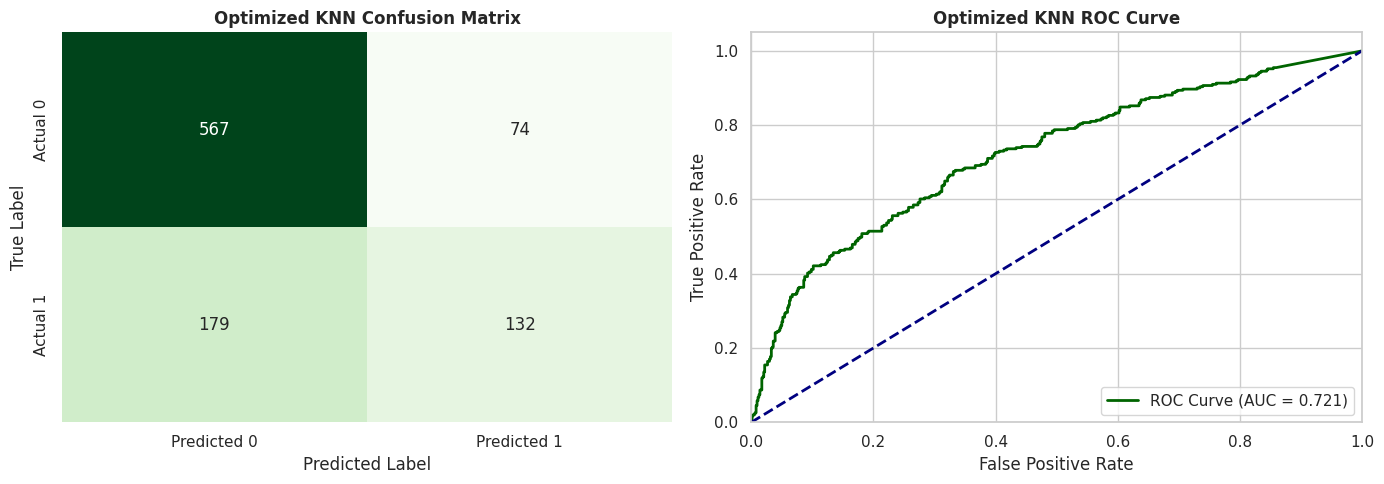


 Optimized KNN validation charts saved directly to your shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/team_knn_optimized_evaluation.png


In [ ]:
sns.set_theme(style="whitegrid")
fig_best_knn, axes_best_knn = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Optimized KNN
cm_best_knn = confusion_matrix(y_val, y_pred_best_knn)
sns.heatmap(cm_best_knn, annot=True, fmt='d', cmap='Greens', ax=axes_best_knn[0], cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
axes_best_knn[0].set_title('Optimized KNN Confusion Matrix', fontweight='bold')
axes_best_knn[0].set_xlabel('Predicted Label')
axes_best_knn[0].set_ylabel('True Label')

# ROC Curve for Optimized KNN
fpr_best_knn, tpr_best_knn, _ = roc_curve(y_val, y_pred_proba_best_knn)
axes_best_knn[1].plot(fpr_best_knn, tpr_best_knn, color='darkgreen', lw=2, label=f'ROC Curve (AUC = {auc_score_best_knn:.3f})')
axes_best_knn[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes_best_knn[1].set_xlim([0.0, 1.0])
axes_best_knn[1].set_ylim([0.0, 1.05])
axes_best_knn[1].set_xlabel('False Positive Rate')
axes_best_knn[1].set_ylabel('True Positive Rate')
axes_best_knn[1].set_title('Optimized KNN ROC Curve', fontweight='bold')
axes_best_knn[1].legend(loc="lower right")

plt.tight_layout()

# Save optimized KNN evaluation plot
output_plot_path_best_knn = file_path.replace('super_dataset_C_train.csv', 'team_knn_optimized_evaluation.png')
plt.savefig(output_plot_path_best_knn, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Optimized KNN validation charts saved directly to your shared Drive folder at:\n   {output_plot_path_best_knn}")


## Model Comparison

In [ ]:
print("\n Model Comparison (ROC-AUC) ")

print(f"Logistic Regression ROC-AUC: {auc_score:.4f}")
print(f"Baseline KNN ROC-AUC:      {auc_score_knn:.4f}")
print(f"Optimized KNN ROC-AUC:     {auc_score_best_knn:.4f}")

print("\n--- Detailed Comparison ---")
if auc_score > auc_score_best_knn:
    print(f"The Logistic Regression model (ROC-AUC: {auc_score:.4f}) performed better than the Optimized KNN model (ROC-AUC: {auc_score_best_knn:.4f}).")
elif auc_score_best_knn > auc_score:
    print(f"The Optimized KNN model (ROC-AUC: {auc_score_best_knn:.4f}) performed better than the Logistic Regression model (ROC-AUC: {auc_score:.4f}).")
else:
    print("Both Logistic Regression and Optimized KNN models performed similarly.")

print("\nSummary: Logistic Regression currently shows the strongest performance based on ROC-AUC on the validation set.")


 Model Comparison (ROC-AUC) 
Logistic Regression ROC-AUC: 0.8290
Baseline KNN ROC-AUC:      0.6859
Optimized KNN ROC-AUC:     0.7212

--- Detailed Comparison ---
The Logistic Regression model (ROC-AUC: 0.8290) performed better than the Optimized KNN model (ROC-AUC: 0.7212).

Summary: Logistic Regression currently shows the strongest performance based on ROC-AUC on the validation set.


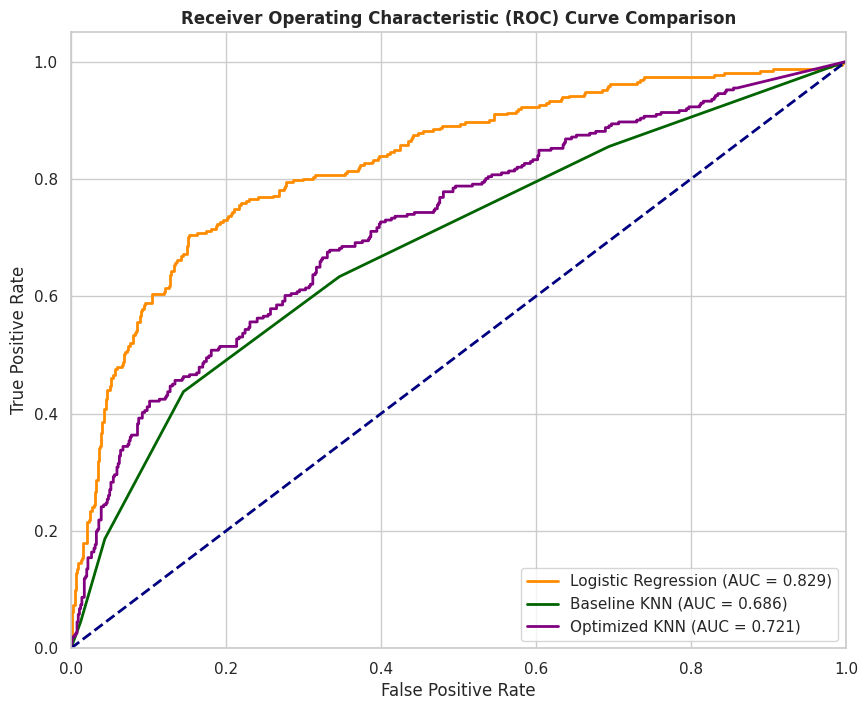


 Model comparison chart saved to: /content/drive/MyDrive/Hackathon_05 06/team_model_roc_auc_comparison.png


In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot(fpr_knn, tpr_knn, color='darkgreen', lw=2, label=f'Baseline KNN (AUC = {auc_score_knn:.3f})')
plt.plot(fpr_best_knn, tpr_best_knn, color='purple', lw=2, label=f'Optimized KNN (AUC = {auc_score_best_knn:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True)

# Save the comparison plot
output_comparison_plot_path = file_path.replace('super_dataset_C_train.csv', 'team_model_roc_auc_comparison.png')
plt.savefig(output_comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Model comparison chart saved to: {output_comparison_plot_path}")

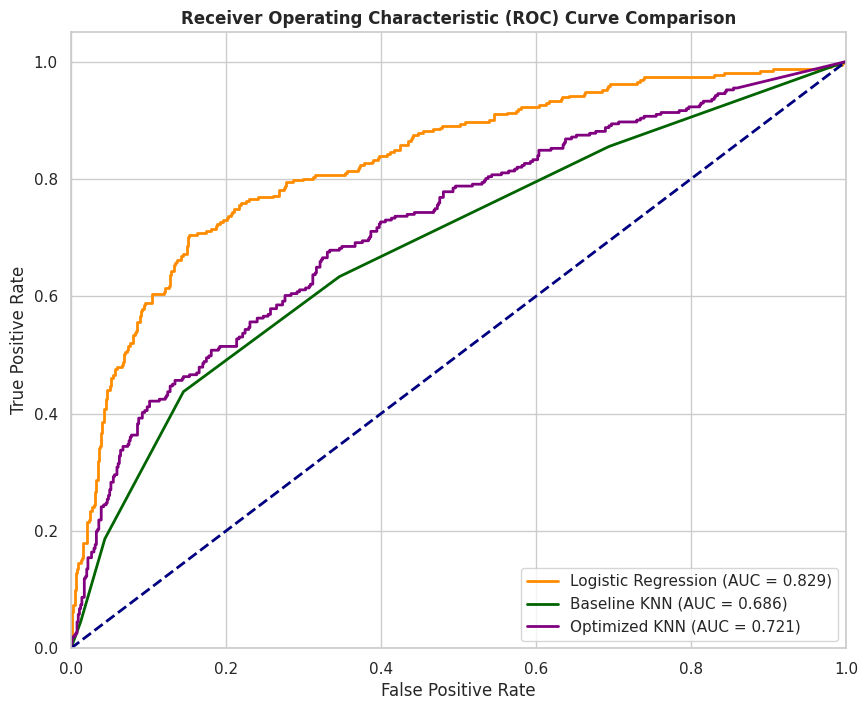


This comparative ROC curve was previously saved to: /content/drive/MyDrive/Hackathon_05 06/team_model_roc_auc_comparison.png


In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot(fpr_knn, tpr_knn, color='darkgreen', lw=2, label=f'Baseline KNN (AUC = {auc_score_knn:.3f})')
plt.plot(fpr_best_knn, tpr_best_knn, color='purple', lw=2, label=f'Optimized KNN (AUC = {auc_score_best_knn:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()
print(f"\nThis comparative ROC curve was previously saved to: {output_comparison_plot_path}")

## Applying Models to Testing Data

In [ ]:
# 1. Load the testing data
print("\nLoading testing data...")
test_file_path = file_path.replace('super_dataset_C_train.csv', 'super_dataset_C_test.csv')

if os.path.exists(test_file_path):
    df_test = pd.read_csv(test_file_path)
    print(f"SUCCESS! Loaded testing data from: {test_file_path}")
    print(f"  Dimensions: {df_test.shape[0]} rows, {df_test.shape[1]} columns")
else:
    raise FileNotFoundError(
        f"ERROR: Could not find testing data at '{test_file_path}'.\n"
        "FIX: Ensure 'super_dataset_C_test.csv' exists in your shared Drive folder."
    )

# Assuming 'respondent_id' is the identifier and 'covid_vaccine' is not present in test set (or if it is, it's the target to drop)
# If 'covid_vaccine' is in test set, we should remove it to form X_test.
# For submission, we usually predict probabilities for a given respondent_id.

# Store respondent_ids for submission
respondent_ids = df_test['respondent_id']

# Prepare X_test (remove 'respondent_id' and the target if it exists)
# We need to ensure X_test has the same columns in the same order as X_train (X_model)

X_test_model = df_test.drop(columns=['respondent_id'], errors='ignore')

# Ensure the columns match exactly between training and testing features
# This is crucial for consistent model application
missing_cols = set(X_model.columns) - set(X_test_model.columns)
for c in missing_cols:
    X_test_model[c] = 0 # Add missing columns with default value (e.g., 0 for one-hot encoded features)

X_test_model = X_test_model[X_model.columns] # Reorder columns to match training set

print("Testing data prepared for prediction.")


Loading testing data...
SUCCESS! Loaded testing data from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_test.csv
  Dimensions: 4749 rows, 65 columns
Testing data prepared for prediction.


In [ ]:
# 2. Make predictions with Logistic Regression
print("\nMaking predictions with Logistic Regression...")
predictions_log_reg_proba = log_reg.predict_proba(X_test_model)[:, 1]

# 3. Make predictions with Optimized KNN
print("Making predictions with Optimized KNN...")
predictions_best_knn_proba = best_knn_model.predict_proba(X_test_model)[:, 1]

print("Predictions completed for both models.")


Making predictions with Logistic Regression...
Making predictions with Optimized KNN...
Predictions completed for both models.


In [ ]:
# 4. Save predictions to separate CSV files

# Logistic Regression predictions
output_predictions_lr_path = file_path.replace('super_dataset_C_train.csv', 'team_logistic_regression_predictions.csv')

predictions_lr_df = pd.DataFrame({
    'respondent_id': respondent_ids,
    'logistic_regression_proba': predictions_log_reg_proba
})

predictions_lr_df.to_csv(output_predictions_lr_path, index=False)

print(f"\nLogistic Regression predictions saved to: {output_predictions_lr_path}")
display(predictions_lr_df.head())

# Optimized KNN predictions
output_predictions_knn_path = file_path.replace('super_dataset_C_train.csv', 'team_optimized_knn_predictions.csv')

predictions_knn_df = pd.DataFrame({
    'respondent_id': respondent_ids,
    'optimized_knn_proba': predictions_best_knn_proba
})

predictions_knn_df.to_csv(output_predictions_knn_path, index=False)

print(f"\nOptimized KNN predictions saved to: {output_predictions_knn_path}")
display(predictions_knn_df.head())


Logistic Regression predictions saved to: /content/drive/MyDrive/Hackathon_05 06/team_logistic_regression_predictions.csv


,respondent_id,logistic_regression_proba
0,4757,0.178282
1,4758,0.166544
2,4759,0.222368
3,4760,0.157550
4,4761,0.076720



Optimized KNN predictions saved to: /content/drive/MyDrive/Hackathon_05 06/team_optimized_knn_predictions.csv


,respondent_id,optimized_knn_proba
0,4757,0.215079
1,4758,0.000000
2,4759,0.202078
3,4760,0.163978
4,4761,0.102582



Step 7: Initializing SHAP Interpretability Pipeline...
SUCCESS! SHAP values successfully computed for the validation partition.


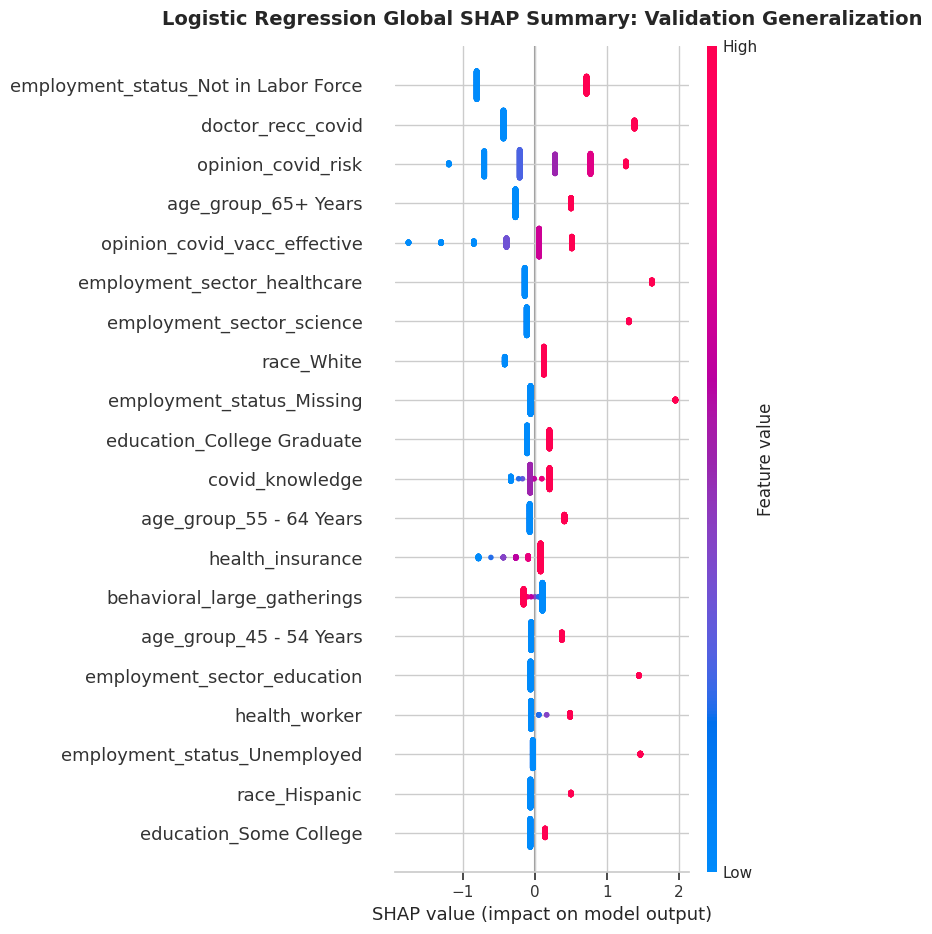


SHAP summary plot saved successfully to your shared Drive folder at:
   /content/drive/MyDrive/Hackathon_05 06/team_logistic_shap_summary.png

Generating interactive local Force Plot for respondent index 0...


In [ ]:
#XAI
import shap

print("\nStep 7: Initializing SHAP Interpretability Pipeline...")

X_val_shap = X_val.copy()
if 'respondent_id' in X_val_shap.columns:
    X_val_shap = X_val_shap.drop(columns=['respondent_id'])
    print("Notice: 'respondent_id' detected and stripped from SHAP matrix to prevent data leakage.")

explainer = shap.LinearExplainer(log_reg, X_val_shap)

shap_values = explainer.shap_values(X_val_shap)

plt.figure(figsize=(11, 6))
if isinstance(shap_values, list):
    shap_summary_target = shap_values[1]
elif len(shap_values.shape) == 3:  # Multi-class format shape
    shap_summary_target = shap_values[:, :, 1]
else:
    shap_summary_target = shap_values

shap.summary_plot(shap_summary_target, X_val_shap, show=False)
plt.title('Logistic Regression Global SHAP Summary: Validation Generalization', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()

output_shap_path = file_path.replace('super_dataset_C_train.csv', 'team_logistic_shap_summary.png')
plt.savefig(output_shap_path, dpi=300, bbox_inches='tight')
plt.show()

print("\nGenerating interactive local Force Plot for respondent index 0...")
shap.initjs()
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

shap.force_plot(base_val, shap_summary_target[0], X_val_shap.iloc[0])